
## - 23MS121 
## - Manish Behera

### Q1


In [2]:
import numpy as np
import matplotlib.pyplot as plt

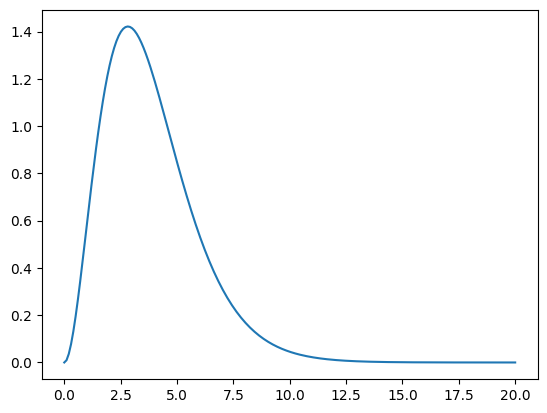

In [19]:
def f(x):
    if x <= 0:
        return 0
    return x**3 / (np.exp(x) - 1)

xs = np.linspace(0.0, 20.0, num=200)
ys = [f(x) for x in xs]
plt.plot(xs, ys);


In [6]:
# parameters 
x0 = 2.8 #around the peak of the function
b = 1.0


def w(x, b, x0):
    return 1.0 / (b + (x - x0)**2)

# def y(x) and then invert it to get x(y).
# y(x) = integral from 0 to x of 1/(b + (z-x0)^2) dz
 
# Now the CDF y(x) = int w(z) dz from 0 to x
def cdf_y(x, b, x0):
    return (1/np.sqrt(b)) * (np.arctan((x-x0)/np.sqrt(b)) - np.arctan(-x0/np.sqrt(b)))

# And the inverse CDF x(y) = solve for x in terms of y
def inv_cdf_x(y, b, x0):
    return x0 + np.sqrt(b) * np.tan(y * np.sqrt(b) + np.arctan(-x0/np.sqrt(b)))

# The new function to integrate over a uniform distribution y
def g(y, b, x0): # g(y) = f(x(y)) / w(x(y))
    x = inv_cdf_x(y, b, x0)
    return f(x) / w(x, b, x0)

# Monte Carlo integration
def mc_integration(n_samples, b, x0):
    ys = np.random.rand(n_samples)
    integral_sum = 0
    for y in ys:
        integral_sum += g(y, b, x0)
    return integral_sum / n_samples

# Perform the integration
n_samples = 100000
integral_value = mc_integration(n_samples, b, x0)

print(f"Number of samples: {n_samples}")
print(f"Calculated integral: {integral_value}")
print(f"Exact value: {np.pi**4 / 15}")
print(f"Absolute error: {abs(integral_value - np.pi**4 / 15)}")


Number of samples: 100000
Calculated integral: 1.9380725630790685
Exact value: 6.493939402266828
Absolute error: 4.555866839187759


### Q2

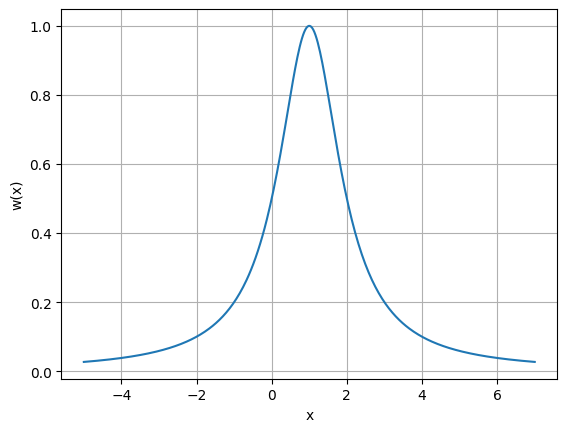

In [18]:
# (a) Plot the distribution
def w(x):
    return 1 / (1 + (x - 1)**2)

x_vals = np.linspace(-5, 7, 400)
y_vals = w(x_vals)

plt.plot(x_vals, y_vals)
plt.xlabel("x")
plt.ylabel("w(x)")
plt.grid(True)
plt.show()


In [14]:
# (b) Metropolis 
x0 = 0.5
n = 1000000
stepsize = 1.0 # As per instruction "maximum step size 1"

store = np.zeros(n)
for i in range(n):
    store[i] = x0
    dx = stepsize * (np.random.rand() - 0.5) * 2 #[-1, 1]
    x1 = x0 + dx
    r = w(x1) / w(x0)
    # Accept the step with a probability a = min(1, r)
    if r >= 1:
        x0 = x1
    else:
        p = np.random.rand()
        if p <= r:
            x0 = x1


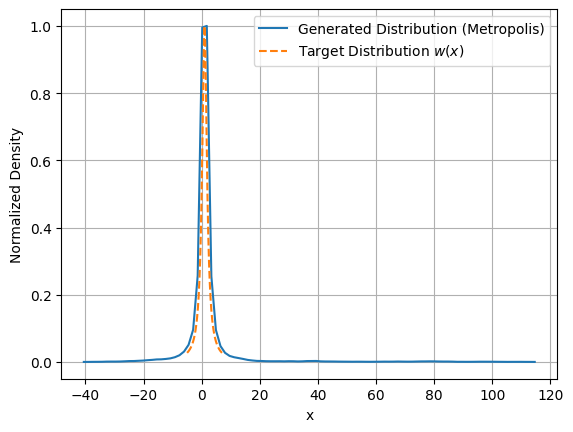

In [17]:
# Target distribution
x_w = np.linspace(-5, 7, 400)
y_w = w(x_w)
y_w_normalized = y_w / np.max(y_w)

# Generated data histogram
values, edges = np.histogram(store, bins=100, density=True)
midpoints = (edges[:-1] + edges[1:]) / 2

# Normalize generated data
values_normalized = values / np.max(values)

plt.plot(midpoints, values_normalized, label='Generated Distribution (Metropolis)')
plt.plot(x_w, y_w_normalized, label='Target Distribution $w(x)$', linestyle='--')
plt.xlabel("x")
plt.ylabel("Normalized Density")
plt.grid(True)
plt.legend()
plt.show()

note how the generated distribution stays close to the peak of w(x) and avoids the tails.